# **한글사용 처리**


---

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt   #시각화를 위한 라이브러리

# 레티나 디스플레이를 지원하도록 해서 한글이 흐릿하게 보이는 현상 개선
%config InlineBackend.figure_format = 'retina'

#한글 나눔 폰트 사용설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

 #해당 폰트를 기본 폰트가 되도록 설정
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 16 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

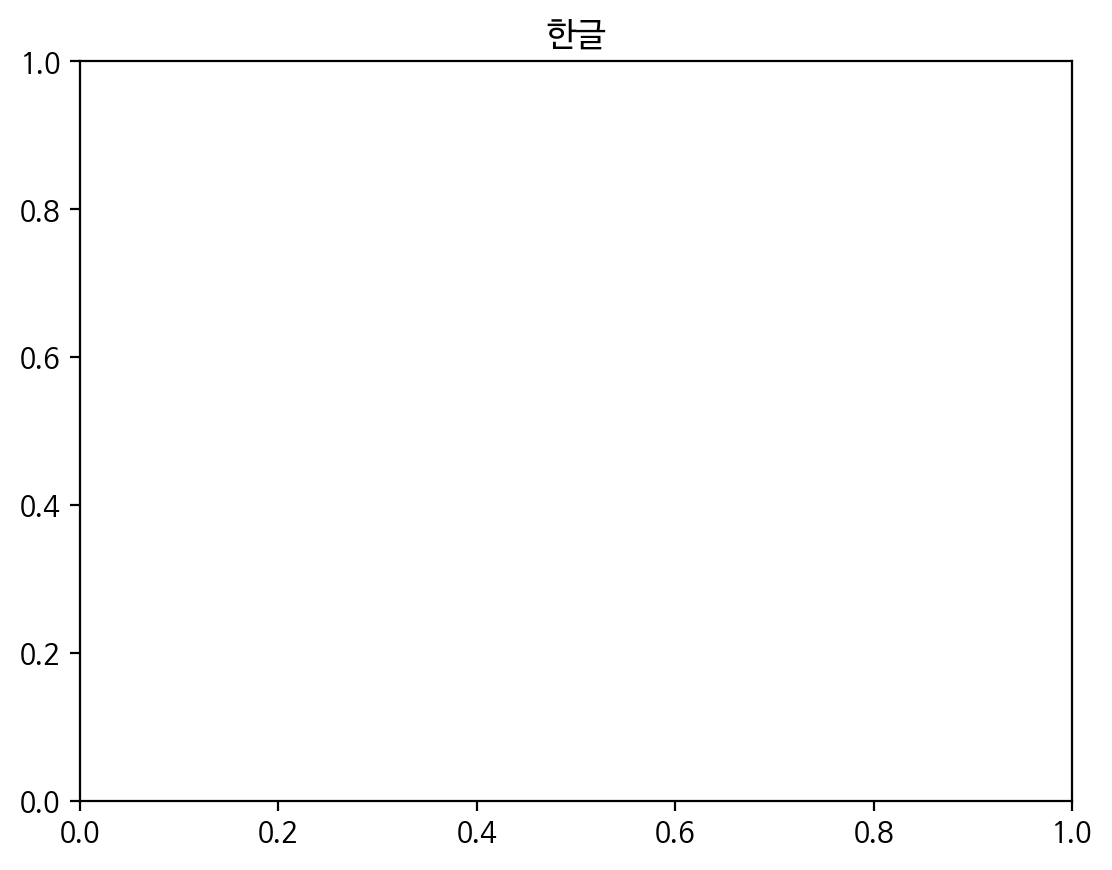

In [2]:
plt.title('한글')
plt.show()

# 해결문제


---
기상개황 자료를 이용하여 월별 불쾌지수를 계산하고 불쾌지수가 높음이상인 월을 구하시오.


https://kosis.kr/statHtml/statHtml.do?orgId=735&tblId=DT_A1040&vw_cd=MT_ZTITLE&list_id=215_215A_735_73503_A&seqNo=&lang_mode=ko&language=kor&obj_var_id=&itm_id=&conn_path=MT_ZTITLE

+ 불쾌지수 공식

  + DI = 0.81 \* Ta + 0.01 \* RH * (0.99 \* Ta - 14.3) + 46.3

  >+ DI: 불쾌지수
  >+Ta: 건구온도(평균기온)
  >+RH: 상대습도(평균상대습도)

+ 불쾌지수 단계

  + 매우높음: 80이상
  + 높음: 75이상 80미만
  + 보통: 68이상 75미만
  + 낮음: 68미만

In [3]:
#pandas 라이브러리 추가
import pandas as pd

In [4]:
#코랩에서 사용할 파일을 업로드하기
from google.colab import files
files.upload()

Saving 기상개황.csv to 기상개황.csv


{'기상개황.csv': b'\xbf\xf9\xba\xb0(1),\xc6\xf2\xb1\xd5\xb1\xe2\xbf\xc2 (\xa1\xc9),\xc6\xf2\xb1\xd5\xc3\xd6\xb0\xed\xb1\xe2\xbf\xc2 (\xa1\xc9),\xc3\xd6\xb0\xed\xb1\xd8\xb0\xaa\xb1\xe2\xbf\xc2 (\xa1\xc9),\xc6\xf2\xb1\xd5\xc3\xd6\xc0\xfa\xb1\xe2\xbf\xc2 (\xa1\xc9),\xc3\xd6\xc0\xfa\xb1\xd8\xb0\xaa\xb1\xe2\xbf\xc2 (\xa1\xc9),\xb0\xad\xbc\xf6\xb7\xae (\xa7\xae),\xc6\xf2\xb1\xd5\xbb\xf3\xb4\xeb\xbd\xc0\xb5\xb5 (%),\xc3\xd6\xbc\xd2\xbb\xf3\xb4\xeb\xbd\xc0\xb5\xb5 (%),\xc6\xf2\xb1\xd5 \xc7\xd8\xb8\xe9\xb1\xe2\xbe\xd0 (hPa),\xc0\xcc\xbd\xbd\xc1\xa1 \xbf\xc2\xb5\xb5 (\xa1\xc9),\xc6\xf2\xb1\xd5\xbf\xee\xb7\xae (1/10),\xc0\xcf\xc1\xb6\xbd\xc3\xb0\xa3 (hr),\xc3\xd6\xbd\xc9\xbd\xc5\xc0\xfb\xbc\xb3 (\xa7\xaf),\xc6\xf2\xb1\xd5\xc7\xb3\xbc\xd3\xb9\xd9\xb6\xf7 (m/s),\xc3\xd6\xb4\xeb\xc7\xb3\xbc\xd3\xb9\xd9\xb6\xf7 (m/s),\xc3\xd6\xb4\xeb\xbc\xf8\xb0\xa3\xc7\xb3\xbc\xd3 (m/s)\r\n\xbf\xac\xb0\xa3,14.2,19.1,37,10.1,-12,1507.3,67,1,1016.3,7.3,4.8,2298.6,-,1.6,12.6,23.5\r\n1\xbf\xf9,0.3,4.9,13.8,-3.6,-12,26.7,46,

In [6]:
#cp949 방식으로 인코딩된 기상개황.csv 파일을 불러와서
#df라는 이름의 데이터 프레임에 저장하기
df = pd.read_csv('기상개황.csv',encoding='cp949',header=0)

In [7]:
#수치 계산을 위한 numpy 라이브러리 불러오기
import numpy as np

In [9]:
#방법1: '평균기온 (℃) > 20 -> '더움', '평균기온 (℃)' > 10 -> '쾌적' 그 외 -> '추움'



In [ ]:
#방법2: '평균기온 (℃) > 20 -> '더움', '평균기온 (℃)' > 10 -> '쾌적' 그 외 -> '추움'



In [ ]:
#열 확인



In [ ]:
#필요한 자료 추출
df2 =
df2

In [ ]:
# 열명변경

df2

In [ ]:
#경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 불쾌지수 계산
Ta =
RH =



불쾌지수 단계






*   매우높음: 80이상
*   높음: 75이상 80미만
*   보통: 68이상 75미만
*   낮음: 68미만





In [ ]:
# 불쾌지수가 높음이상(75이상)



In [ ]:
#'단계'가 '매우높음', '높음' 에 해당하는 '월별'에 있는 데이터를 리스트로 출력 - [방법1]


In [ ]:
#'단계'가 '매우높음', '높음' 에 해당하는 '월별'에 있는 데이터를 리스트로 출력 - [방법2]


In [ ]:
#'불쾌지수' >= 75 인 '월별'에 있는 데이터를 리스트로 출력


In [ ]:
#행인덱스 변경
df2 =
df2

In [ ]:
#그래프 그리기1


In [ ]:
#그래프 그리기2

In [ ]:
#그래프 그리기3
df2[['평균기온', '평균상대습도']].plot(marker='o', figsize=(10, 5))
df2['불쾌지수'].plot(kind='bar', color='g', label='불쾌지수')
plt.
plt.title('연간 불쾌지수 현황', fontsize=20)
plt.
plt.
plt.xlabel('')
plt.show()